In [2]:
import pandas as pd

df = pd.read_csv("clean_df_Auto.csv",index_col=0)

df.head()

,symboling,normalized-losses,make,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,horsepower-binned,fuel-type-diesel,fuel-type-gas,aspiration-std,aspiration-turbo
0,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,0.890278,...,5000.0,21,8.703704,13495.0,11.190476,Low,False,True,True,False
1,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,0.890278,...,5000.0,21,8.703704,16500.0,11.190476,Low,False,True,True,False
2,1,122,alfa-romero,two,hatchback,rwd,front,94.5,0.822681,0.909722,...,5000.0,19,9.038462,16500.0,12.368421,Medium,False,True,True,False
3,2,164,audi,four,sedan,fwd,front,99.8,0.848630,0.919444,...,5500.0,24,7.833333,13950.0,9.791667,Low,False,True,True,False
4,2,164,audi,four,sedan,4wd,front,99.4,0.848630,0.922222,...,5500.0,18,10.681818,17450.0,13.055556,Low,False,True,True,False


In [3]:
# data grouping is useful for categorical data

df1 = df[['drive-wheels','body-style','price']]
df_grp = df1.groupby(['drive-wheels','body-style'], as_index=False).mean()  # grouping by 'drive-wheels' and 'body-style' for its mean price
df_grp

,drive-wheels,body-style,price
0,4wd,hatchback,7603.000000
1,4wd,sedan,12647.333333
2,4wd,wagon,9095.750000
3,fwd,convertible,11595.000000
4,fwd,hardtop,8249.000000
5,fwd,hatchback,8396.387755
6,fwd,sedan,9811.800000
7,fwd,wagon,9997.333333
8,rwd,convertible,23949.600000
9,rwd,hardtop,24202.714286


In [4]:
df_grp = df1.groupby(['body-style','drive-wheels'], as_index=False).mean()  # grouping by 'body-style' and 'drive-wheels' for its mean price
df_grp

,body-style,drive-wheels,price
0,convertible,fwd,11595.000000
1,convertible,rwd,23949.600000
2,hardtop,fwd,8249.000000
3,hardtop,rwd,24202.714286
4,hatchback,4wd,7603.000000
5,hatchback,fwd,8396.387755
6,hatchback,rwd,14337.777778
7,sedan,4wd,12647.333333
8,sedan,fwd,9811.800000
9,sedan,rwd,21711.833333


In [5]:
# pivot the grouping on a variable for clearer data visualization

df_grp = df1.groupby(['drive-wheels','body-style'], as_index=False).mean()  # grouping by 'drive-wheels' and 'body-style' for its mean price
df_pivot = df_grp.pivot(index='drive-wheels', columns='body-style') # pivoting over the body-style column

df_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  NaN           NaN   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

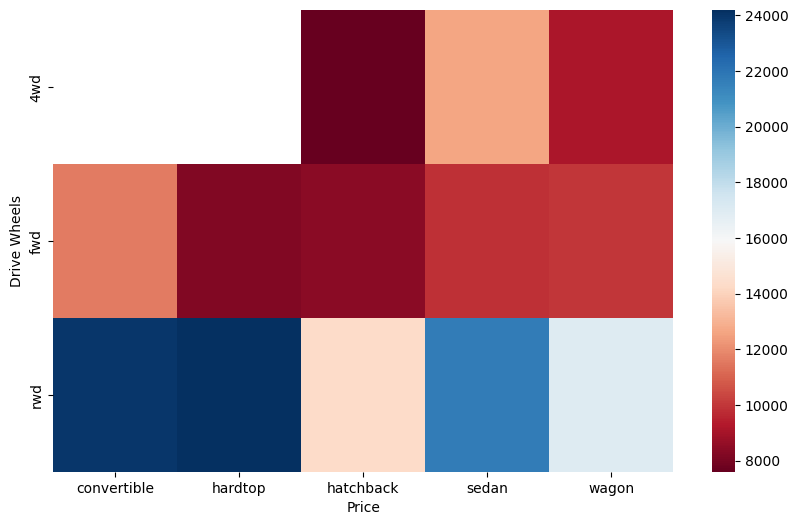

In [6]:
# data visualization using Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
hm = sns.heatmap(df_pivot, cmap='RdBu', yticklabels=df_pivot.index.get_level_values(0), xticklabels=df_pivot.columns.get_level_values(1))
hm.set_ylabel("Drive Wheels")
hm.set_xlabel("Price")
plt.show()

In [7]:
import numpy as np

file_path='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv'

headers = ["symboling","normalized-losses","make","fuel-type","aspiration","num-of-doors","body-style","drive-wheels","engine-location","wheel-base","length",
           "width","height","curb-weight","engine-type","num-of-cylinders","engine-size","fuel-system","bore","stroke","compression-ratio","horsepower",
           "peak-rpm","city-mpg","highway-mpg","price"]

df = pd.read_csv(file_path, header=None, names=headers)
df.replace("?", np.nan, inplace=True)
df.dropna(subset=["price"], axis=0, inplace=True)
df.reset_index(drop=True, inplace=True) # re-number the index after deleting rows above
df[["bore","stroke"]] = df[["bore","stroke"]].astype("float")
df[["price"]] = df[["price"]].astype("float")
df[["peak-rpm"]] = df[["peak-rpm"]].astype("float")
# Replace by mean value for "horsepower" column
avg_horsepower = df["horsepower"].astype("float").mean(axis=0)
df["horsepower"] = df["horsepower"].replace(np.nan, avg_horsepower)
df["horsepower"] = df["horsepower"].astype(int)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000.0,19,26,16500.0
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500.0,24,30,13950.0
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500.0,18,22,17450.0


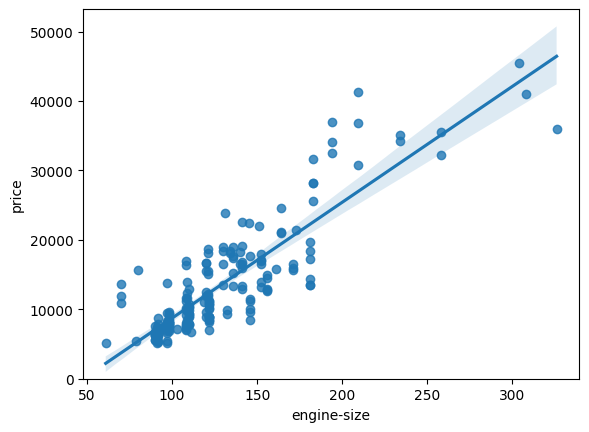

In [8]:
# data visualization using correlation -positive or negative correlation

# positive correlation
cr = sns.regplot(x="engine-size", y="price", data=df)
plt.ylim(0,)
plt.show()

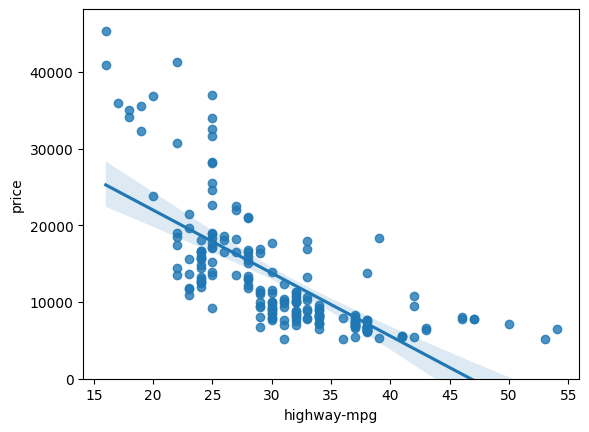

In [9]:
# negative strong correlation 
cr = sns.regplot(x="highway-mpg", y="price", data=df)
plt.ylim(0,)
plt.show()

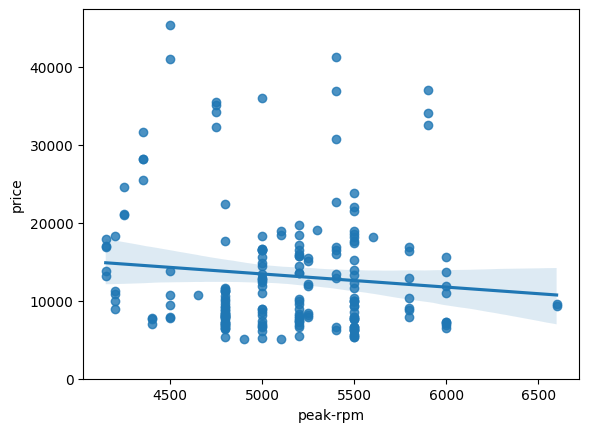

In [10]:
# negative weak correlation 
cr = sns.regplot(x="peak-rpm", y="price", data=df)
plt.ylim(0,)
plt.show()

In [11]:
# Correlation Methods

# 1. Pearson Correlation - measure the strength of the correlation with :
#    Correlation Coefficient -> +1 implies large positive relation, -1 implies large negative relation, 0 means no correlation
#    P-value -> certainty of the correlation coefficient; <0.001 implies strong certainty, <0.05 implies moderate, <0.1 implies weak certainty, >0.1 no certainty

from scipy import stats

pc = stats.pearsonr(df['horsepower'],df['price'])
print(f"Pearson Correlation: {pc.statistic:.8f}")
print(f"P-value {pc.pvalue:.8f}")



Pearson Correlation: 0.80972904
P-value 0.00000000


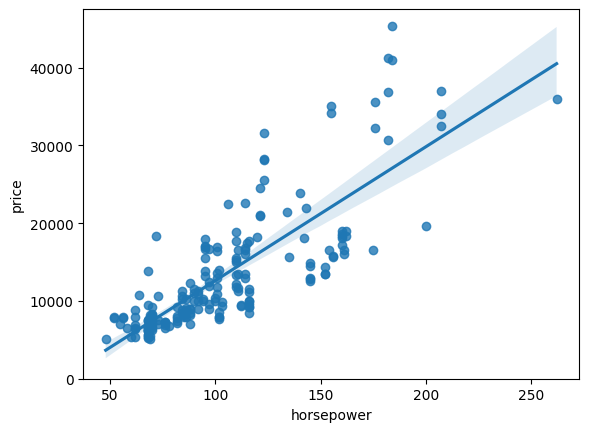

In [12]:
cr = sns.regplot(x="horsepower", y="price", data=df)
plt.ylim(0,)
plt.show()

In [13]:
pv = df.pivot_table(columns='horsepower',values='price')
pv

horsepower,48,52,55,56,58,60,62,64,68,69,...,160,161,162,175,176,182,184,200,207,262
price,5151.0,7885.0,7099.0,7843.0,6479.0,5399.0,6961.333333,10795.0,6965.421053,7030.9,...,18282.6,16278.0,18685.0,16503.0,33900.0,36318.333333,43180.0,19699.0,34528.0,36000.0


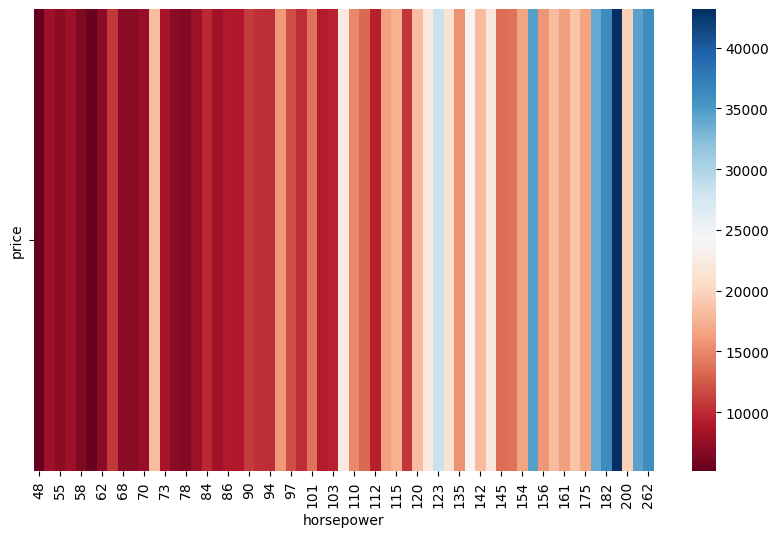

In [14]:
plt.figure(figsize=(10,6))
hm = sns.heatmap(pv, cmap='RdBu')
#hm.set_ylabel("Drive Wheels")
#hm.set_xlabel("Price")
plt.show()

In [15]:
# Chi-Square Test - a statistical method for determining any significant association between two categorical variables.
# This test is widely use for analyzing survey data, experment results, and observational studies.
#   H0 - Null Hypothesis assumes no association between the categorical variables.
#   H1 - Alternative Hypothesis assumes there is significant association between variables.


In [16]:
df_num = df.select_dtypes(include=['float64','int64','int','float'])
df_num

,symboling,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000.0,21,27,13495.0
1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000.0,21,27,16500.0
2,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,5000.0,19,26,16500.0
3,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102,5500.0,24,30,13950.0
4,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115,5500.0,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1,109.1,188.8,68.9,55.5,2952,141,3.78,3.15,9.5,114,5400.0,23,28,16845.0
197,-1,109.1,188.8,68.8,55.5,3049,141,3.78,3.15,8.7,160,5300.0,19,25,19045.0
198,-1,109.1,188.8,68.9,55.5,3012,173,3.58,2.87,8.8,134,5500.0,18,23,21485.0
199,-1,109.1,188.8,68.9,55.5,3217,145,3.01,3.40,23.0,106,4800.0,26,27,22470.0


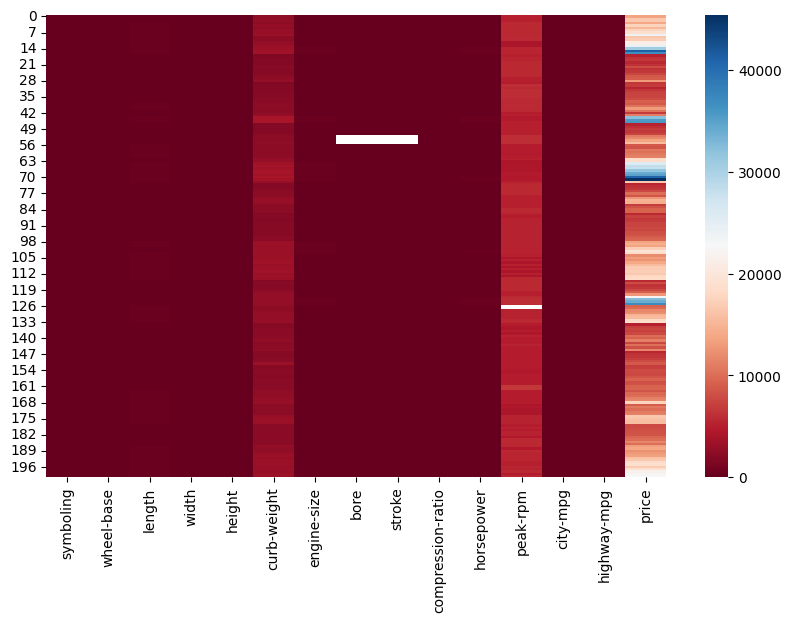

In [17]:
plt.figure(figsize=(10,6))
hm = sns.heatmap(df_num, cmap='RdBu')
plt.show()